# Tarea 3 - Jefersson Manzanares Fernández - C34509

Importa los paquetes necesarios para ejecutar ambos casos.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.inspection import DecisionBoundaryDisplay

Se definen las funciones necesarias para resolver ambos problemas.

In [16]:
def generate_v1() -> np.ndarray:
    """
    Genera un array con 3 puntos v_i definidos en las posiciones indicadas
    por el problema.
        
    Returns:
        np.ndarray: Array de posiciones de los puntos v_i.
    """
    v = np.zeros([3,2])
    v[0] = [1,0]
    v[1] = [np.cos(2*np.pi/3),np.sin(2*np.pi/3)]
    v[2] = [np.cos(4*np.pi/3),np.sin(4*np.pi/3)]

    return v


def generate_v2(n=10) -> np.ndarray:
    """
    Genera un array con n puntos v_i definidos de forma aleatoria en una 
    distribucion uniforme en [0,1] en 2 dimensiones.

    Args:
    n (int, optional): Cantidad de puntos. Default: 10.
        
    Returns:
        np.ndarray: Array de posiciones de los puntos v_i.
    """
    return np.random.rand(n,2)


def classify(r_vals: np.ndarray, v: np.ndarray) -> np.ndarray:
    """
    Genera un array que indica cual de los puntos v_i esta mas cerca de cada punto r_j.

    Args:
        r_vals (np.ndarray): Lista de puntos r_j.
        v (np.ndarray)L Lista de puntos v_i.
        
    Returns:
        np.ndarray: Array con el indice del punto v_i mas cercano.
    """
    return [np.argmin(np.linalg.norm(v - r, axis=1)) for r in r_vals]  

## Problema 1
### 1-) Datos

In [17]:
#Cantidad de puntos aleatorios
N = 30

#Genera los puntos v
v_vals1 = generate_v1()

#Genera los puntos aleatorios r
r_vals1 = np.random.normal(0, 1, (N,2))

#Clasifica los puntos r
y_vals1 = classify(r_vals1,v_vals1)

### 2-) Optimización

In [18]:
#Crea el modelo que estima la clasificacion, usando "hinge"
clf_model_h1 = SGDClassifier(loss='hinge').fit(r_vals1, y_vals1)

#Crea el modelo que estima la clasificacion, usando "log_loss"
clf_model_ll1 = SGDClassifier(loss='log_loss').fit(r_vals1, y_vals1)

### 3-) Discusión

Partiendo de que existe una funcion $f(x)$ que aprende del modelo, la cual se define (para el caso en 1D) como:

$$
f(x_i) = w \cdot x_i + b,
$$

las funciones $h$ utilizan la función $f(x)$ de forma distinta dependiendo de la función de pérdida empleada.

En el caso de *hinge* la clase se determina según el signo de $f(x)$:

$$
h(y_i, f(x_i)) = \max(0, 1 - y_i f(x_i)),
$$

Esto da lugar a fronteras de decisión rígidas y a modelos que buscan maximizar el margen entre clases, por lo que la optimización depende principalmente de los puntos cercanos a la frontera de decisión.

En el caso de *log_loss*, la función $f(x)$ se utiliza para obtener una probabilidad:

$$
h(y_i, f(x_i)) = \log\left(1 + \exp(-y_i f(x_i))\right),
$$

En este caso, la optimización considera todos los puntos del conjunto de datos y produce fronteras de decisión más suaves.

### 4-) Visualización

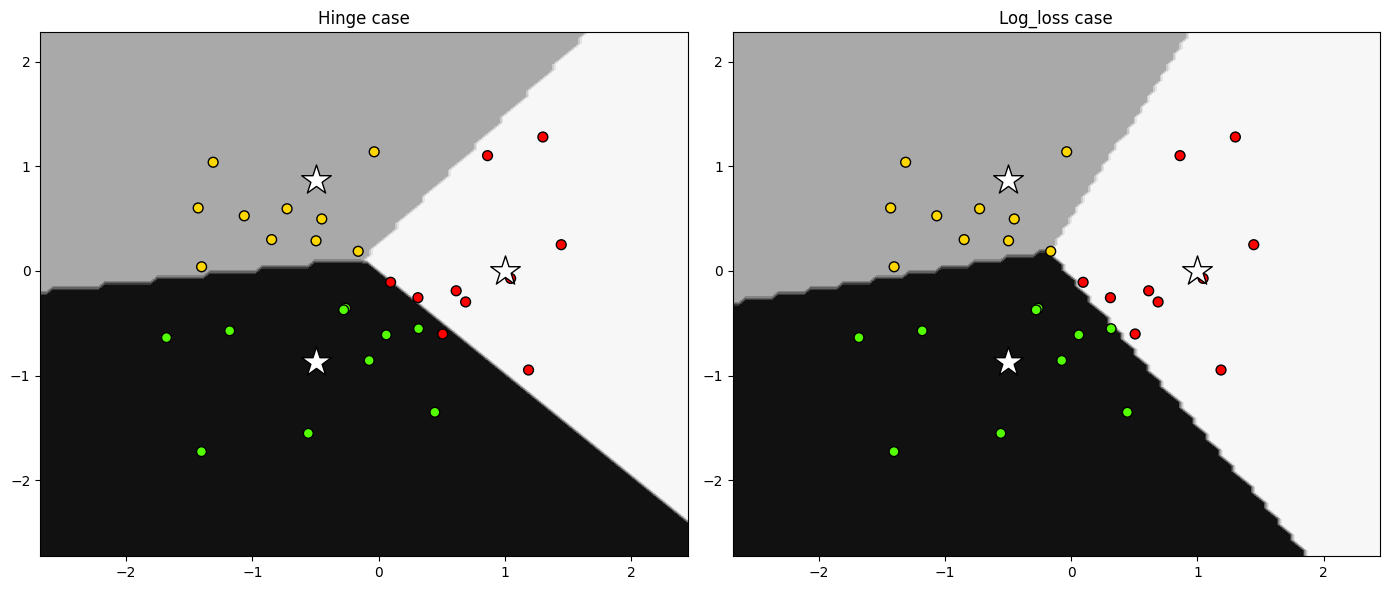

In [19]:
fig, (ax_h, ax_ll) = plt.subplots(1,2, figsize=(14,6))

#Genera el mapa con las areas estimadas por el modelo "hinge"
DecisionBoundaryDisplay.from_estimator(
    clf_model_h1,
    r_vals1,
    cmap="Greys",
    ax=ax_h,
    response_method="predict",
)

#Genera el mapa con las areas estimadas por el modelo "log-loss"
DecisionBoundaryDisplay.from_estimator(
    clf_model_ll1,
    r_vals1,
    cmap="Greys",
    ax=ax_ll,
    response_method="predict",
)

axes = [ax_h, ax_ll]
for ax in axes:

    #Grafica los puntos aleatorios con color segun si clasificacion
    ax.scatter(
        r_vals1[:,0], 
        r_vals1[:,1], 
        c=y_vals1, 
        cmap="prism",
        s=50,
        edgecolors='black',
        linewidths=1
    )
    
    #Grafica los valores de v de mnera que resalten
    ax.scatter(
        v_vals1[:,0],
        v_vals1[:,1],
        marker='*',
        s=500,
        color='white',
        edgecolors='black',
        linewidths=1
    )

#Configura el ploteo final
ax_h.set_title("Hinge case")
ax_ll.set_title("Log_loss case")
plt.tight_layout()
plt.show()

## Problema 2
### 1-) Datos

In [75]:
#Cantidad de puntos aleatorios
N = 100

#Genera los puntos v
v_vals2 = generate_v2(10)

#Genera los puntos aleatorios r
r_vals2 = np.random.rand(N,2)

#Clasifica los puntos r
y_vals2 = classify(r_vals2,v_vals2)

### 2-) Optimización

In [76]:
#Crea el modelo que estima la clasificacion, usando "hinge"
#clf_model_h2 = SGDClassifier(loss='hinge', max_iter=10000, alpha=1e-3).fit(r_vals2, y_vals2)
clf_model_h2 = SGDClassifier(
    loss='hinge',
    max_iter=100000,
    alpha=1e-4,
    eta0=0.001,
    tol=None,
    random_state=0,
    average=True
).fit(r_vals2, y_vals2)

#Crea el modelo que estima la clasificacion, usando "log_loss"
#clf_model_ll2 = SGDClassifier(loss='log_loss', max_iter=10000, alpha=1e-3).fit(r_vals2, y_vals2)
clf_model_ll2 = SGDClassifier(
    loss='log_loss',
    max_iter=100000,
    alpha=1e-4,
    eta0=0.001,
    tol=None,
    random_state=0,
    average=True
).fit(r_vals2, y_vals2)

### 3-) Visualización

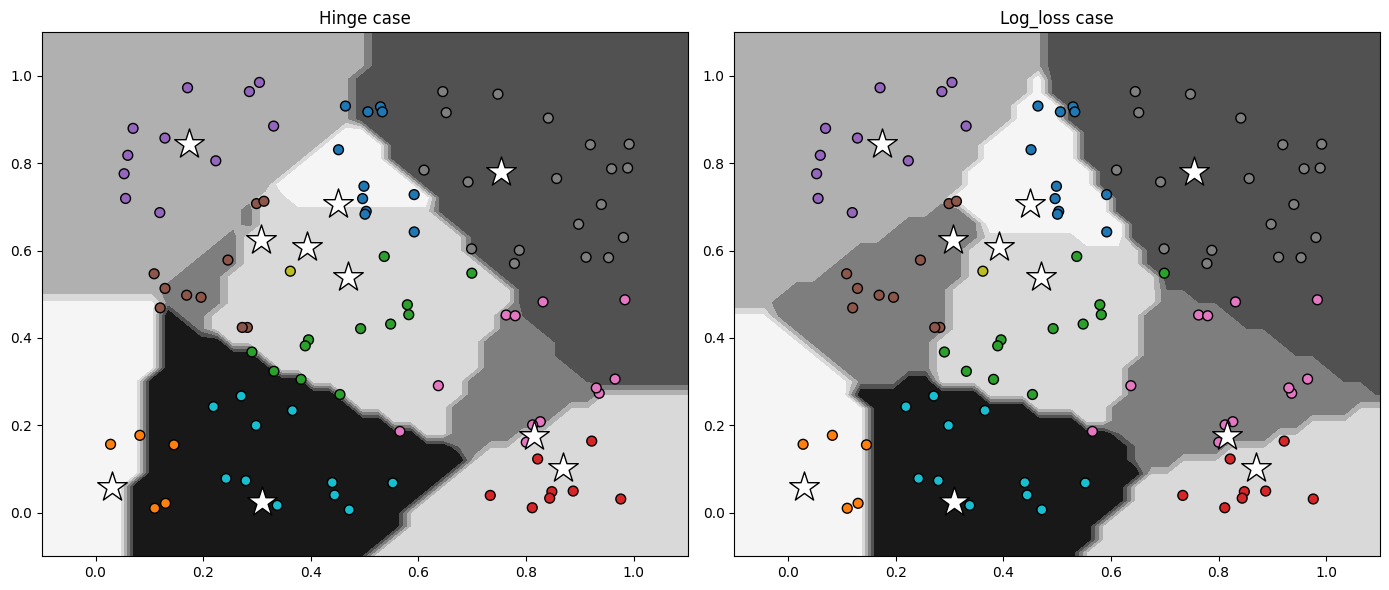

In [78]:
fig, (ax_h, ax_ll) = plt.subplots(1,2, figsize=(14,6))

#Genera el mapa con las areas estimadas por el modelo "hinge"
DecisionBoundaryDisplay.from_estimator(
    clf_model_h2,
    r_vals2,
    cmap="Greys",
    ax=ax_h,
    response_method="predict",
)

#Genera el mapa con las areas estimadas por el modelo "log-loss"
DecisionBoundaryDisplay.from_estimator(
    clf_model_ll2,
    r_vals2,
    cmap="Greys",
    ax=ax_ll,
    response_method="predict",
)

axes = [ax_h, ax_ll]
for ax in axes:
    
    #Grafica los puntos aleatorios con color segun si clasificacion
    ax.scatter(
        r_vals2[:,0], 
        r_vals2[:,1], 
        c=y_vals2, 
        cmap='tab10',
        s=50,
        edgecolors='black',
        linewidths=1
    )
    
    #Grafica los valores de v de mnera que resalten
    ax.scatter(
        v_vals2[:,0],
        v_vals2[:,1],
        marker='*',
        s=500,
        color='white',
        edgecolors='black',
        linewidths=1
    )

    ax.set_xlim([-0.1,1.1])
    ax.set_ylim([-0.1,1.1])

#Configura el ploteo final
ax_h.set_title("Hinge case")
ax_ll.set_title("Log_loss case")
plt.tight_layout()
plt.show()

## 4-) Discusión

Intente utilizando varios ajustes para que se generaran las 10 zonas para cada punto, pero aun asi se me siguen mezclando zonas, creo que tiene que ver con las limitaciones de que f(x) es una funcion lineal, al trabajar con 10 puntos el modelo se rompe, en especial si estos se generan muy cerca unos de otros y no hay suficientes muestras para definir una frontera clara.